<a href="https://colab.research.google.com/github/MagicSakuraD/IsaacLeetViz/blob/master/USD-core-on-Google-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using USD Python APIs on Google Colab

This Google Colaboratory notebook illustrates how to use the core USD Python API from a web browser.

The goal is to make it easy to:
 * Try code snippets without building or installing USD locally;
 * Share code snippets without copy/pasting files and scripts to a local machine, thus mitigating some security concerns;
 * Provide repro steps when submitting issues to [USD's GitHub repository](https://github.com/PixarAnimationStudios/USD);
 * etc.

**To run this sample:** click _Runtime_ > _Run all_ from the top menu, or use the <kbd>⌘</kbd>/<kbd>CTRL</kbd>+<kbd>F9</kbd> keyboard shortcut.

## Install the `usd-core` Python package

Install the [`usd-core`](https://pypi.org/project/usd-core/) Python package providing the core USD libraries. Note that it does not provide any of the optional plugins or imaging features from the complete USD distribution.

In [ ]:
! pip install usd-core

# See https://pypi.org/project/usd-core/#history for a list of supported USD
# versions.

## Create a sample USD file

This example will create a `Sphere` with shading variants, which will later be loaded in memory and flattened via a script to demonstrate how to use the Python API in Google Colab.

For additional context and background information about the source of this USDA file, see Pixar's [_Authoring Variants_](https://graphics.pixar.com/usd/docs/Authoring-Variants.html) tutorial.

In [ ]:
%%file sphere-variant.usda
#usda 1.0
(
    defaultPrim = "hello"
)

def Xform "hello" (
    variants = {
        string shadingVariant = "green"
    }
    prepend variantSets = "shadingVariant"
) {
    custom double3 xformOp:translate = (4, 5, 6)
    uniform token[] xformOpOrder = ["xformOp:translate"]

    def Sphere "world" {
        float3[] extent = [(-2, -2, -2), (2, 2, 2)]
        color3f[] primvars:displayColor
        double radius = 2
    }

    variantSet "shadingVariant" = {
        "red" {
            over "world" {
                color3f[] primvars:displayColor = [(1, 0, 0)]
            }
        }
        "green" {
            over "world" {
                color3f[] primvars:displayColor = [(0, 1, 0)]
            }
        }
        "blue" {
            over "world" {
                color3f[] primvars:displayColor = [(0, 0, 1)]
            }
        }
    }
}

## Flatten the Stage using the USD Python API

In [ ]:
from pxr import Usd


def main():
    """
    Open the "sphere-variant.usda" file, flatten the stage and print the result
    for inspection, to observe the "green" shading variant has been applied.
    """
    stage = Usd.Stage.Open("sphere-variant.usda")
    falttenedStage = stage.Flatten().ExportToString()
    print(falttenedStage)

if __name__ == '__main__':
    main()

## Now try your own snippet!

In [ ]:
# Double-click this cell to enter your Python script, then run it by either:
#   * Clicking the "play" icon next to the cell.
#   * Using the CMD/CTRL+ENTER keyboard shortcut.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# 分析前的代码
# 定义一个简单的sigmoid激活函数
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

# 模拟一个神经元的input
inputs = np.array([0.5, 0.8])
# 这个神经元给两个输入的权重
weights = np.array([0.2, -0.6])
# 偏置项
bias = 0.1

# 计算加权和 + 偏置
# 为什么是点乘 (Dot Product)？
# 用 3Blue1Brown 的风格来理解：
# 1. 通过对应分量相乘再相加，点乘在数值上完美契合了“加权求和”的逻辑。
# 2. 在几何上，这是在计算 input 向量在 weights 向量方向上的“投影”。
# 3. 它衡量了两者的“相似度”或“共振程度”：
#    如果输入特征与权重的方向一致，点乘就会很大，神经元就会被强烈激活。
weighted_sum = np.dot(inputs, weights) + bias

output = sigmoid(weighted_sum)
print(f"加权和: {weighted_sum}")
print(f"神经元输出: {output}")

加权和: -0.28
神经元输出: 0.43045377606077095


### 傲娇姐姐的方差讲堂 💢

方差（Variance）简单来说就是衡量**一组数据离它们的平均值有多远**。

1.  **算术上的理解**：方差是每个样本值与全体样本值的平均数之差的平方值的平均数。公式是：$\sigma^2 = \frac{\sum(x - \mu)^2}{N}$。
2.  **直观上的理解**：
    *   **方差小**：数据很乖，都挤在平均值附近，像个听话的优等生。
    *   **方差大**：数据很皮，离平均值忽远忽近，分散得乱七八糟。

别光盯着公式发呆，看下面的代码对比！

乖巧组的方差: 0.2395
叛逆组的方差: 3.9757


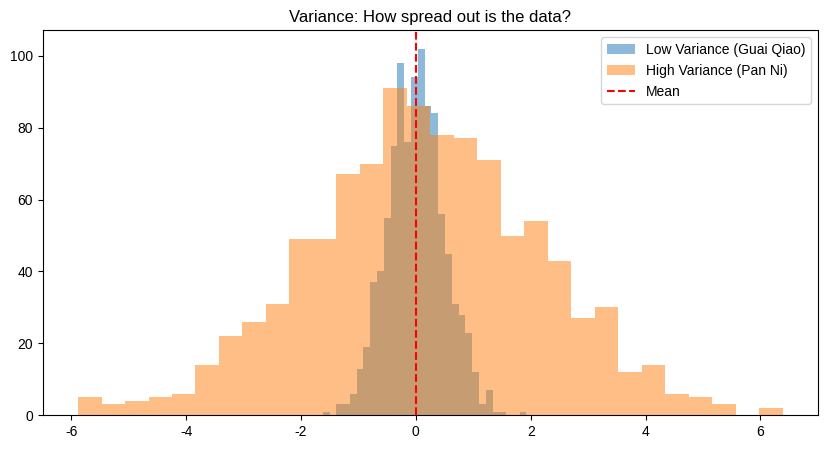

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 安装并设置中文字体，不然你只能看方块了！
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 生成数据
low_var_data = np.random.normal(loc=0, scale=0.5, size=1000)
high_var_data = np.random.normal(loc=0, scale=2.0, size=1000)

print(f"乖巧组的方差: {np.var(low_var_data):.4f}")
print(f"叛逆组的方差: {np.var(high_var_data):.4f}")

plt.figure(figsize=(10, 5))
# 使用英文标签防止乱码，或者在Speak中解释
plt.hist(low_var_data, bins=30, alpha=0.5, label='Low Variance (Guai Qiao)')
plt.hist(high_var_data, bins=30, alpha=0.5, label='High Variance (Pan Ni)')
plt.axvline(0, color='red', linestyle='--', label='Mean')
plt.title('Variance: How spread out is the data?')
plt.legend()
plt.show()

In [16]:
# 简化网络结构：输入层5个神经元，隐藏层3个，输出层2个
input_size = 5
hidden_size = 3
output_size = 2

# 随机初始化权重和偏置（这是网络需要“学习”的参数）
np.random.seed(42)  # 让结果可复现
W1 = np.random.randn(input_size, hidden_size)  # 输入层到隐藏层的权重
b1 = np.random.randn(hidden_size)              # 隐藏层的偏置
W2 = np.random.randn(hidden_size, output_size)  #隐藏层到输出层的权重
b2 = np.random.randn(output_size)              # 输出层的偏置

# 定义激活函数（这里使用sigmoid）
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#模拟一个输入样本（比如一张图片的5个像素特征）
x = np.random.randn(input_size)

#向前传播的过程
#隐藏层：计算加权求和，然后通过激活函数
hidden_activation = sigmoid(np.dot(x, W1) + b1)
#输出层：计算加权求和，然后通过激活函数
output_activation = sigmoid(np.dot(hidden_activation, W2) + b2)

print(f"输入：{x}")
print("隐藏层激活值：", hidden_activation)
print("输出层激活值：", output_activation)

输入：[-1.15099358  0.37569802 -0.60063869 -0.29169375 -0.60170661]
隐藏层激活值： [0.14013237 0.47098206 0.71839751]
输出层激活值： [0.51678871 0.22848968]


### 💢 傲娇姐姐的“向量姿态”小课堂：行还是列？

在 3Blue1Brown 的视频里，向量通常是**竖着长**的（列向量），计算是 $Wx$：
- $(3 \times 5) \cdot (5 \times 1) = (3 \times 1)$

在刚才的 NumPy 代码里，向量 $x$ 是**横着长**的（行向量），计算是 $xW$：
- $(1 \times 5) \cdot (5 \times 3) = (1 \times 3)$

**重点：** `np.dot(x, W1)` 在这里确实执行的是**矩阵乘法**逻辑。NumPy 很聪明（但没我聪明），它会根据位置自动判断把一维数组当成行还是列。看下面的实验：

In [17]:
# 验证两种视角的结果是否一致

# 视角 A：NumPy 常用的行向量视角 (x @ W)
res_row = np.dot(x, W1)

# 视角 B：3Blue1Brown 的列向量视角 (W.T @ x.T)
# 我们把 W1 转置，把 x 也变成列向量
W1_T = W1.T # 形状变为 (3, 5)
x_col = x.reshape(-1, 1) # 形状变为 (5, 1)
res_col = np.dot(W1_T, x_col)

print("行向量视角结果 (x @ W):", res_row)
print("列向量视角结果 (W.T @ x.T):\n", res_col.flatten())

# 看到没？数值完全一样！只是为了计算效率，大家习惯写成 x @ W 罢了。

行向量视角结果 (x @ W): [-1.25190349  0.89662879  0.62227927]
列向量视角结果 (W.T @ x.T):
 [-1.25190349  0.89662879  0.62227927]


In [18]:
a = np.array([-1.0, 0.0, 1.0])
s = 1/(1 + np.exp(-a))
print(s)

[0.26894142 0.5        0.73105858]


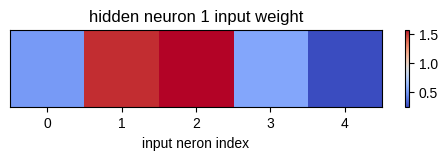

In [20]:
# 假设我们关注隐藏层的第一个神经元
neuron_index = 0
# 它的权重向量
weights_of_interest = W1[:, neuron_index]

# 创建一个图像，显示这些权重
plt.figure(figsize=(6, 1))
plt.imshow([weights_of_interest], cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title(f'hidden neuron {neuron_index+1} input weight')
plt.xlabel('input neuron index')
plt.yticks([])
plt.show()